**Copying images to training, validation, and test directories**

In [1]:
import pathlib
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.applications import ResNet50

2025-03-20 11:22:36.190841: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
new_base_dir = pathlib.Path("cats_vs_dogs_small")

**Instantiating the ResNet50 convolutional base**

In [3]:
conv_base = ResNet50(
    weights="imagenet",  # Pre-trained on ImageNet
    include_top=False,   # Exclude the fully-connected layer at the top
    input_shape=(180, 180, 3)  # Input shape for your images
)

2025-03-20 11:22:44.632015: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-20 11:22:44.637177: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-20 11:22:44.637395: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [4]:
conv_base.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 180, 180, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 186, 186, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 90, 90, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 90, 90, 64)           256       ['conv1_conv[0][0]']          
 on)                                                                                       

__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 input_1 (InputLayer)        [(None, 180, 180, 3)]        0         []                            


 conv1_pad (ZeroPadding2D)   (None, 186, 186, 3)          0         ['input_1[0][0]']             


...

 on)                                                                                              


Total params: 23587712 (89.98 MB)


Trainable params: 23534592 (89.78 MB)


Non-trainable params: 53120 (207.50 KB)


__________________________________________________________________________________________________


#### Fast feature extraction without data augmentation

**Extracting the VGG16 features and corresponding labels**

In [5]:
import numpy as np

def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.resnet.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

In [6]:

from keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


Found 1000 files belonging to 2 classes.


Found 2000 files belonging to 2 classes.


In [7]:
train_features, train_labels =  get_features_and_labels(train_dataset)
val_features, val_labels =  get_features_and_labels(validation_dataset)
test_features, test_labels =  get_features_and_labels(test_dataset)

2025-03-20 11:22:46.898437: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8800
2025-03-20 11:22:47.158315: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


1/1 [==============================] - 0s 18ms/step


1/1 [==============================] - ETA: 0s

1/1 [==============================] - 1s 1s/step


1/1 [==============================] - ETA: 0s

...

1/1 [==============================] - 0s 20ms/step


1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 20ms/step


1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 19ms/step


In [8]:
random_numbers = np.random.normal(size=(1000, 16))
dataset = tf.data.Dataset.from_tensor_slices(random_numbers)

In [9]:
for i, element in enumerate(dataset):
    print(element.shape)
    if i >= 2:
        break

(16,)
(16,)
(16,)


In [10]:
batched_dataset = dataset.batch(32)
for i, element in enumerate(batched_dataset):
    print(element.shape)
    if i >= 2:
        break

(32, 16)
(32, 16)
(32, 16)


In [11]:
reshaped_dataset = dataset.map(lambda x: tf.reshape(x, (4, 4)))
for i, element in enumerate(reshaped_dataset):
    print(element.shape)
    if i >= 2:
        break

(4, 4)
(4, 4)
(4, 4)


**Displaying the shapes of the data and labels yielded by the `Dataset`**

In [12]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)


**Defining and training the densely connected classifier**

In [13]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.resnet.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
conv_base.trainable = False

model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [14]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
      filepath="resnet_from_scratch",
      save_best_only=True,
      monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30


2025-03-20 11:23:03.451001: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7efaf2beccd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-03-20 11:23:03.451031: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2025-03-20 11:23:03.456317: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-03-20 11:23:03.540967: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


INFO:tensorflow:Assets written to: resnet_from_scratch/assets396 - accuracy: 0.9163 


INFO:tensorflow:Assets written to: resnet_from_scratch/assets


63/63 [==============================] - 17s 233ms/step - loss: 14.5598 - accuracy: 0.9165 - val_loss: 2.4486 - val_accuracy: 0.9760
Epoch 2/30
63/63 [==============================] - 4s 64ms/step - loss: 7.6443 - accuracy: 0.9570 - val_loss: 4.6347 - val_accuracy: 0.9750
Epoch 3/30
63/63 [==============================] - 4s 63ms/step - loss: 6.0619 - accuracy: 0.9615 - val_loss: 3.4694 - val_accuracy: 0.9760
Epoch 4/30
63/63 [==============================] - 4s 64ms/step - loss: 4.6191 - accuracy: 0.9665 - val_loss: 3.3677 - val_accuracy: 0.9790
Epoch 5/30
63/63 [==============================] - 4s 62ms/step - loss: 5.1524 - accuracy: 0.9670 - val_loss: 2.7586 - val_accuracy: 0.9820
Epoch 6/30
INFO:tensorflow:Assets written to: resnet_from_scratch/assets84 - accuracy: 0.9735    


...

57/63 [==========================>...] - ETA: 0s - loss: 1.2553 - accuracy: 0.9863

59/63 [===========================>..] - ETA: 0s - loss: 1.2128 - accuracy: 0.9868

61/63 [============================>.] - ETA: 0s - loss: 1.1730 - accuracy: 0.9872

63/63 [==============================] - ETA: 0s - loss: 1.1879 - accuracy: 0.9865

63/63 [==============================] - 4s 61ms/step - loss: 1.1879 - accuracy: 0.9865 - val_loss: 2.8573 - val_accuracy: 0.9770


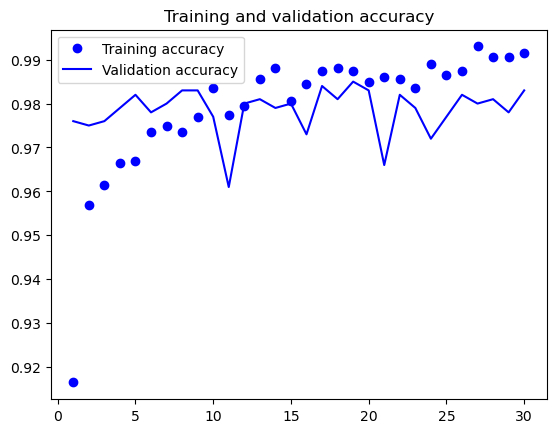

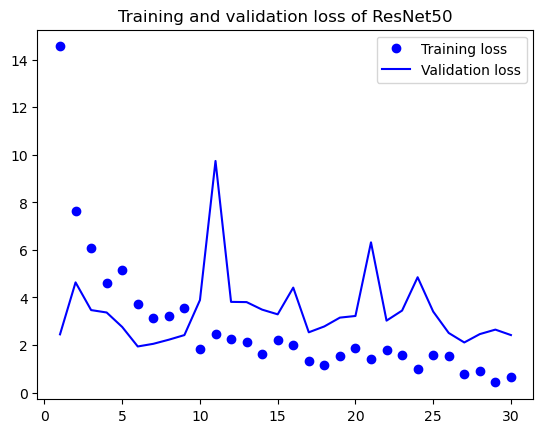

In [15]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss of ResNet50")
plt.legend()
plt.show()

In [16]:
model = keras.models.load_model("resnet_from_scratch")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy ResNet50: {test_acc:.3f}")

63/63 [==============================] - 3s 38ms/step - loss: 4.5031 - accuracy: 0.9735
Test accuracy ResNet50: 0.974


 3/63 [>.............................] - ETA: 2s - loss: 0.3339 - accuracy: 0.9896     

 5/63 [=>............................] - ETA: 2s - loss: 2.1117 - accuracy: 0.9812

 7/63 [==>...........................] - ETA: 2s - loss: 1.5083 - accuracy: 0.9866

 9/63 [===>..........................] - ETA: 2s - loss: 1.2636 - accuracy: 0.9861

...

59/63 [===========================>..] - ETA: 0s - loss: 3.8554 - accuracy: 0.9799

61/63 [============================>.] - ETA: 0s - loss: 3.8083 - accuracy: 0.9800

63/63 [==============================] - ETA: 0s - loss: 3.7169 - accuracy: 0.9805

63/63 [==============================] - 3s 36ms/step - loss: 3.7169 - accuracy: 0.9805


Test accuracy ResNet50: 0.980


In [17]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

**Fine-tuning the model**

In [18]:
model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
INFO:tensorflow:Assets written to: fine_tuning/assetsss: 2.0372 - accuracy: 0.9798      


INFO:tensorflow:Assets written to: fine_tuning/assets


63/63 [==============================] - 17s 238ms/step - loss: 2.0799 - accuracy: 0.9795 - val_loss: 1.6944 - val_accuracy: 0.9820
Epoch 2/30
INFO:tensorflow:Assets written to: fine_tuning/assetsss: 2.0969 - accuracy: 0.9815


INFO:tensorflow:Assets written to: fine_tuning/assets


63/63 [==============================] - 15s 238ms/step - loss: 2.0969 - accuracy: 0.9815 - val_loss: 1.6650 - val_accuracy: 0.9830
Epoch 3/30
63/63 [==============================] - 4s 67ms/step - loss: 1.6985 - accuracy: 0.9860 - val_loss: 1.7395 - val_accuracy: 0.9860
Epoch 4/30
63/63 [==============================] - 4s 67ms/step - loss: 2.8342 - accuracy: 0.9810 - val_loss: 1.9031 - val_accuracy: 0.9850
Epoch 5/30
63/63 [==============================] - 4s 65ms/step - loss: 1.0562 - accuracy: 0.9860 - val_loss: 1.9507 - val_accuracy: 0.9860
Epoch 6/30
63/63 [==============================] - 4s 63ms/step - loss: 2.1533 - accuracy: 0.9835 - val_loss: 2.0602 - val_accuracy: 0.9860
Epoch 7/30
63/63 [==============================] - 4s 63ms/step - loss: 1.4565 - accuracy: 0.9850 - val_loss: 1.9883 - val_accuracy: 0.9860
Epoch 8/30
63/63 [==============================] - 4s 64ms/step - loss: 1.3844 - accuracy: 0.9895 - val_loss: 2.0701 - val_accuracy: 0.9860
Epoch 9/30
63/63 [====

...

57/63 [==========================>...] - ETA: 0s - loss: 1.0220 - accuracy: 0.9907

59/63 [===========================>..] - ETA: 0s - loss: 1.0157 - accuracy: 0.9905

61/63 [============================>.] - ETA: 0s - loss: 0.9824 - accuracy: 0.9908

63/63 [==============================] - ETA: 0s - loss: 0.9962 - accuracy: 0.9905

63/63 [==============================] - 4s 62ms/step - loss: 0.9962 - accuracy: 0.9905 - val_loss: 2.5597 - val_accuracy: 0.9820


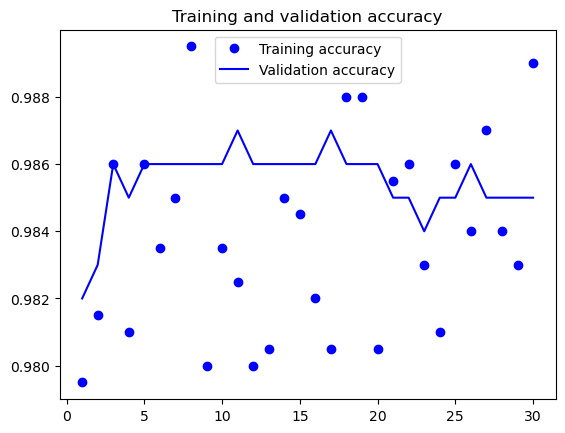

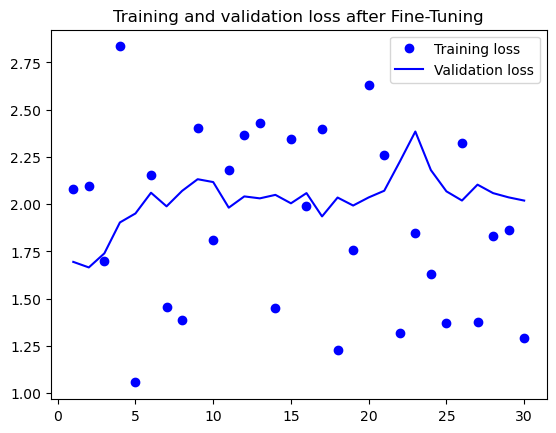

In [19]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss after Fine-Tuning")
plt.legend()
plt.show()

In [20]:
model = keras.models.load_model("fine_tuning")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy after fine-tuning: {test_acc:.3f}")

63/63 [==============================] - 3s 39ms/step - loss: 3.7196 - accuracy: 0.9790
Test accuracy after fine-tuning: 0.979


 3/63 [>.............................] - ETA: 2s - loss: 3.6439 - accuracy: 0.9792     

 5/63 [=>............................] - ETA: 2s - loss: 4.7127 - accuracy: 0.9750

 7/63 [==>...........................] - ETA: 2s - loss: 3.3662 - accuracy: 0.9821

 9/63 [===>..........................] - ETA: 1s - loss: 2.8511 - accuracy: 0.9826

...

59/63 [===========================>..] - ETA: 0s - loss: 3.3656 - accuracy: 0.9804

61/63 [============================>.] - ETA: 0s - loss: 3.4879 - accuracy: 0.9805

63/63 [==============================] - ETA: 0s - loss: 3.4042 - accuracy: 0.9810

63/63 [==============================] - 3s 37ms/step - loss: 3.4042 - accuracy: 0.9810


Test accuracy after fine-tuning: 0.981